In [9]:
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
import pandas as pd

In [10]:
iris = load_iris()

In [19]:
X = iris.data
y = iris.target

In [22]:
X.shape

(150, 4)

<Axes: >

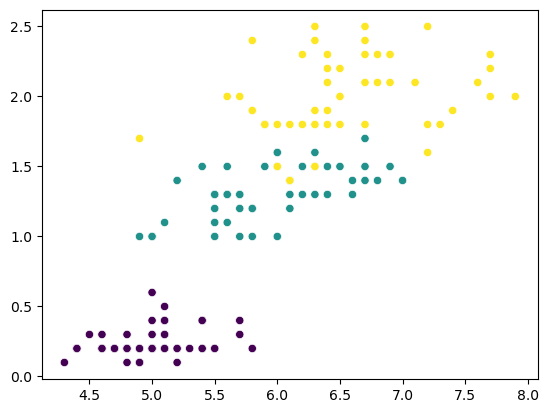

In [26]:
sns.scatterplot(x=X[:,0],y=X[:,3],c=y)

In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [29]:
#elbow method 

wcss = []
for k in range(1,11):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

C:\Users\vaish\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\vaish\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\vaish\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\vaish\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^

In [30]:
wcss

[600.0,
 222.36170496502302,
 140.03275277428648,
 121.63959387793265,
 104.964576662555,
 82.73988592995875,
 71.0478098889349,
 62.58513572337206,
 57.271873961030124,
 51.48552549996766]

<Axes: >

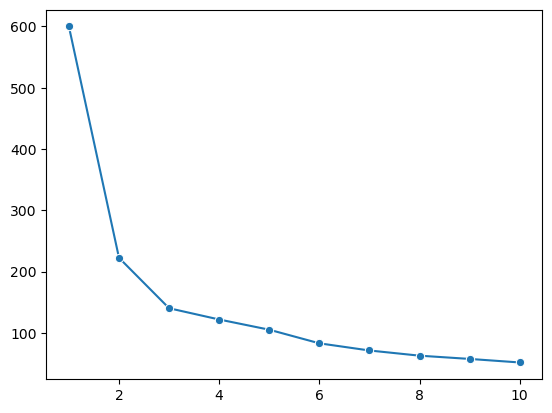

In [31]:
sns.lineplot(x=range(1,11), y=wcss,marker="o")

C:\Users\vaish\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


<Axes: >

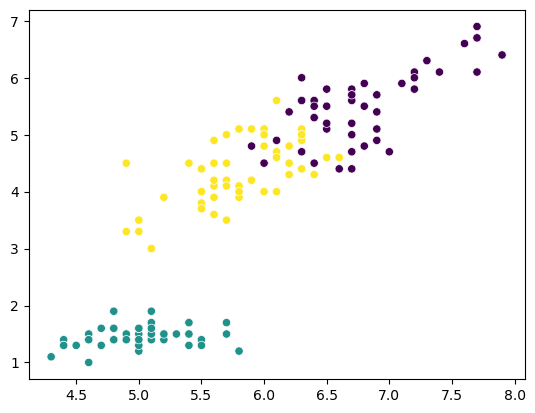

In [33]:
kmeans = KMeans(n_clusters=3)
labels = kmeans.fit_predict(X_scaled)

sns.scatterplot(x=X[:,0],y=X[:,2],c=labels)